# Florida road-works / construction projects — investigating `road-projects preprocess` / `road-projects assemble`

This notebook **imports**
`src/regions/florida/sources/road_projects/{preprocess,assemble}.py` — the
way `schools.ipynb`/`assessments.ipynb` do — runs each stage, and walks
through the main data-preparation decisions with the real fetched data (two
live FDOT ArcGIS REST extracts, already on disk). Full design brief:
[`docs/data/florida/road_projects/README.md`](../../../docs/data/florida/road_projects/README.md).

| file | grain | written by |
|---|---|---|
| `processed/road_projects.parquet` | one row per raw project-item record | `preprocess` |
| `assembled/school_road_match.parquet` | one row per placed `msid` | `assemble` |
| `assembled/school_road_projects.parquet` | one row per `(msid, project)` pair | `assemble` |
| `assembled/school_road_projects_summary.parquet` | one row per placed `msid` | `assemble` |

Covariate Cluster D: a noise wall is frequently one line item inside a
widening/PD&E project; this source exists to control for co-timed road work
as a confounder. Three decisions drove its design, each with the real data
behind it below: (1) two ArcGIS extracts with genuinely different temporal
coverage (`Work_Program_Current` is current-window only, `Active_Construction_Projects`
reaches back to 2009); (2) the `roadway_id`+milepost join needed no spatial
matching, unlike `noise_barriers`, because both extracts share
`road_network`'s own linear-referencing system — checked, not assumed; (3)
matching by `roadway_id` alone would over-attach distant projects, so
`assemble.py` also computes each school's own milepost.

Run with the `311` conda env (geopandas, pandas 3).

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 110
BLUE, RED, GREEN, ORANGE, GREY = "#4C78A8", "#E45756", "#1f6f3f", "#d9822b", "#B0B0B0"


def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.regions.florida.sources.road_projects import preprocess as PRE        # noqa: E402
from src.regions.florida.sources.road_projects import assemble as ASM          # noqa: E402
from src.regions.florida.sources.road_projects import shared as SH             # noqa: E402
from src.regions.florida.sources.road_network.shared import processed_road_network_path  # noqa: E402

FIGDIR = ROOT / "output/figures/florida"
FIGDIR.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    path = FIGDIR / name
    fig.savefig(path, bbox_inches="tight", dpi=130)
    print("  saved", path.relative_to(ROOT))


ROOT

PosixPath('/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution')

## 1. The two live extracts: schema, and genuinely different temporal coverage

In [2]:
wp_construction = PRE.load_raw_work_program("construction")
wp_pde = PRE.load_raw_work_program("pde")
active = PRE.load_raw_active_construction()

print(f"Work_Program_Current / Construction Phase: {len(wp_construction):,} rows, "
      f"{wp_construction.shape[1]} columns")
print(f"Work_Program_Current / PD&E Phase:         {len(wp_pde):,} rows")
print(f"Active_Construction_Projects:               {len(active):,} rows, "
      f"{active.shape[1]} columns")

print("\nWork Program fiscal-year range:", wp_construction["FISCALYR"].min(), "-", wp_construction["FISCALYR"].max())
active_start = pd.to_datetime(pd.to_numeric(active["StartDate"], errors="coerce"), unit="ms")
print("Active Construction StartDate range:", active_start.min().date(), "-", active_start.max().date())

wp_construction[["RDWYID", "BEGSECPT", "ENDSECPT", "FISCALYR", "WPWKMIXN", "WPITSTNM"]].head(3)

Work_Program_Current / Construction Phase: 96,494 rows, 27 columns
Work_Program_Current / PD&E Phase:         19,092 rows
Active_Construction_Projects:               2,428 rows, 20 columns

Work Program fiscal-year range: 2023 - 2030
Active Construction StartDate range: 2009-03-03 - 2026-02-09


,RDWYID,BEGSECPT,ENDSECPT,FISCALYR,WPWKMIXN,WPITSTNM
0,26030000,0.000,4.161000,2024,RESURFACING,CONST.COMPLETE
1,26070000,0.210,1.877000,2027,ADD LANES & RECONSTR,ROW ACQUISITION BEG.
2,26070000,18.796,18.884001,2027,RESURFACING,BIDS RECEIVED


`Work_Program_Current` is confirmed current-window only (its fiscal years
never reach earlier than the mid-2020s — a live `FISCALYR<2020` query
returns zero rows). `Active_Construction_Projects` is **not** current-only
despite the name — it retains completed contracts back to 2009, the only
usable pre-2020 signal from either live service. `assemble.py`/`panel/assemble.py`
lean on `Active_Construction_Projects` for older road-works timing and
`Work_Program_Current` for the finer fiscal-year/phase detail available
2020+.

## 2. The `roadway_id` + milepost join needed no spatial matching — checked, not assumed

Unlike `noise_barriers.fed_route` (free text, forced a nearest-line spatial
join for `road_network`), both extracts key roadways by the same 8-digit
`ROADWAY` id format `road_network.roadway_id` already uses. Before relying
on a direct milepost-overlap join, checked whether the two sources'
milepost *reference frames* actually agree.

In [3]:
road_network = gpd.read_parquet(processed_road_network_path(ROOT))

processed = PRE.preprocess_road_projects(wp_construction, wp_pde, active)
rn_extent = road_network.groupby("roadway_id").agg(rn_min=("begin_post", "min"), rn_max=("end_post", "max"))
rn_extent.index = rn_extent.index.astype(str)

rp = processed.dropna(subset=["roadway_id", "begin_post", "end_post"]).copy()
rp["roadway_id"] = rp["roadway_id"].astype(str)
merged = rp.merge(rn_extent, left_on="roadway_id", right_index=True, how="inner")

tol = 0.25
within = (merged["begin_post"] >= merged["rn_min"] - tol) & (merged["end_post"] <= merged["rn_max"] + tol)
print(f"road_projects rows with roadway_id present in road_network: {len(merged):,} of {len(rp):,} "
      f"({len(merged) / len(rp):.1%})")
print(f"of those, within the roadway\'s own milepost extent (+-{tol} mi): {within.mean():.2%}")

road_projects rows with roadway_id present in road_network: 115,375 of 118,014 (97.8%)
of those, within the roadway's own milepost extent (+-0.25 mi): 99.96%


**99.96%** of matched rows fall within their roadway's own milepost
extent — confirms FDOT really does use one shared linear-referencing system
across `rciroads` and the Work Program / Site Manager extracts (its own
description of the historical archive says it is built "using RCI Basemap
Roads"), not just a coincidence of similar id formats. This is what makes
the direct `roadway_id` + milepost-overlap join in `assemble.py` sound.

## 3. Why `assemble.py` also computes a school's own milepost, not just its `roadway_id`

A `roadway_id` can span a short urban block or many kilometres
(`road_network`'s Open Question 7). Matching by `roadway_id` alone would
attach *every* project ever logged anywhere on that roadway to every school
near it — including ones many miles away. `match_schools_to_roadway`
additionally projects each school onto its matched segment for a
`milepost` (`road_network/linear_ref.py`'s `same_segment` linear
referencing).

placed schools: 5,984 | matched to a roadway: 5,366 (89.7%)


  saved output/figures/florida/road_projects_school_milepost_hist.png


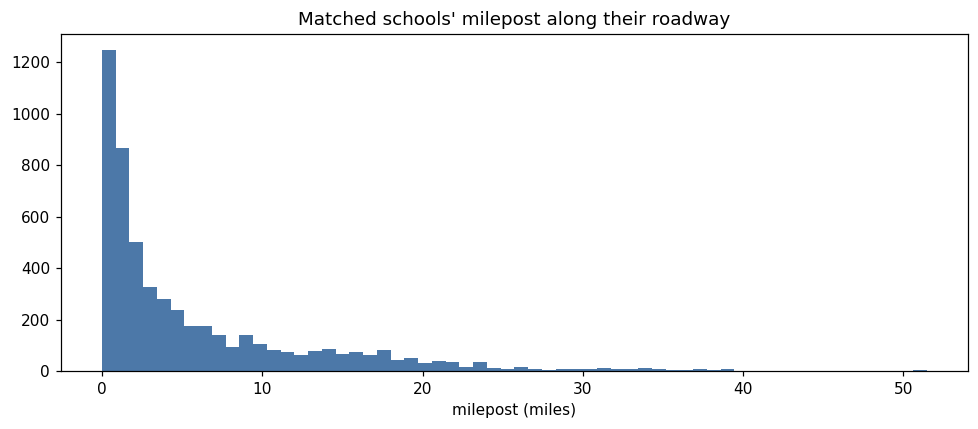

In [4]:
placed = ASM.load_placed_schools(ROOT)
school_road_match = ASM.match_schools_to_roadway(placed, road_network)

matched = school_road_match["roadway_id"].notna()
print(f"placed schools: {len(placed):,} | matched to a roadway: {matched.sum():,} ({matched.mean():.1%})")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(school_road_match.loc[matched, "milepost"], bins=60, color=BLUE)
ax.set_title("Matched schools\' milepost along their roadway")
ax.set_xlabel("milepost (miles)")
fig.tight_layout()
savefig(fig, "road_projects_school_milepost_hist.png")
plt.show()

## 4. Run the full `preprocess` (validates + persists)

In [5]:
report = PRE.run_road_projects_preprocess()
print(json.dumps({k: v for k, v in report.items() if k not in ("saved",)}, indent=1, default=str))
for k, v in report["saved"].items():
    print("wrote", Path(v).relative_to(ROOT))

{
 "raw_rows": {
  "work_program_construction": 96494,
  "work_program_pde": 19092,
  "active_construction": 2428
 },
 "rows": 118014,
 "distinct_roadway_ids": 4676,
 "wall_keyword_rows": 164,
 "columns": [
  "source",
  "roadway_id",
  "begin_post",
  "end_post",
  "fiscal_year",
  "start_date",
  "end_date",
  "work_type",
  "status",
  "description",
  "is_wall_project",
  "cost",
  "fin_proj_num",
  "district",
  "county"
 ]
}
wrote data/florida/road_projects/processed/road_projects.parquet
wrote data/florida/road_projects/processed/road_projects.json


## 5. The `is_wall_project` / `is_widening_project` keyword flags

Cheap regex scans over each project's free-text description — a starting
signal for the "wall built as part of a widening" vs. "standalone barrier"
treatment-split question, not a validated ground truth.

In [6]:
road_projects = pd.read_parquet(SH.processed_projects_path(ROOT))

print("is_wall_project rows:    ", int(road_projects["is_wall_project"].sum()))
print("is_wall_project examples:")
print(road_projects.loc[road_projects["is_wall_project"], "description"].head(5).to_string(index=False))

is_wall_project rows:     164
is_wall_project examples:
     LEWIS BLVD WELCOME WALL SIGN HARLEM COMMUNITY
     LEWIS BLVD WELCOME WALL SIGN HARLEM COMMUNITY
Design Build SR 70 from Lorraine Rd to Bournsid...
      BARRIER ISLAND COMPLETE STREETS IMPROVEMENTS
      BARRIER ISLAND COMPLETE STREETS IMPROVEMENTS


A real false positive surfaces immediately: "LEWIS BLVD WELCOME WALL SIGN HARLEM COMMUNITY" is a welcome sign, not a noise wall -- confirms the keyword scan is exactly the cheap, unvalidated starting signal the design brief frames it as, not a finished treatment-split variable. Manual/spatial cross-checking against `noise_barriers` would be needed before using `is_wall_project` on its own.

## 6. School <-> project matching + county coverage (`assemble`)

In [7]:
report = ASM.run_road_projects_assemble(root=ROOT)
print(json.dumps({k: v for k, v in report.items() if k not in ("saved",)}, indent=1, default=str))
for k, v in report["saved"].items():
    print("wrote", Path(v).relative_to(ROOT))

{
 "generated_at_utc": "2026-09-14T14:20:07+00:00",
 "generated_by": "src/regions/florida/sources/road_projects/assemble.py",
 "max_dist_m": 1000.0,
 "milepost_tolerance_mi": 0.25,
 "schools_placed": 5984,
 "schools_matched": 5366,
 "schools_unmatched": 618,
 "school_road_projects_pairs": 40729,
 "schools_with_a_nearby_project": 2586,
 "schools_with_a_nearby_wall_project": 8
}
wrote data/florida/road_projects/assembled/school_road_match.parquet
wrote data/florida/road_projects/assembled/school_road_projects.parquet
wrote data/florida/road_projects/assembled/school_road_projects_summary.parquet


  saved output/figures/florida/road_projects_nearby_count_hist.png


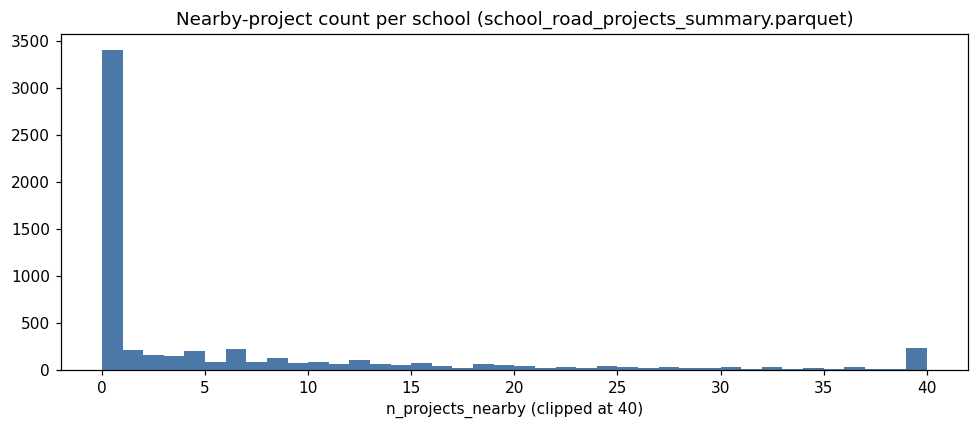

schools with >=1 nearby project: 2,586 of 5,984 placed schools


In [8]:
summary = pd.read_parquet(SH.school_road_projects_summary_path(ROOT))
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(summary["n_projects_nearby"].clip(upper=40), bins=40, color=BLUE)
ax.set_title("Nearby-project count per school (school_road_projects_summary.parquet)")
ax.set_xlabel("n_projects_nearby (clipped at 40)")
fig.tight_layout()
savefig(fig, "road_projects_nearby_count_hist.png")
plt.show()

n_with_nearby = (summary["n_projects_nearby"] > 0).sum()
print(f"schools with >=1 nearby project: {n_with_nearby:,} of {len(summary):,} placed schools")

Coverage is naturally uneven across schools — some sit on roadways FDOT
has logged dozens of work-program items against over the archive's window,
others none at all (either genuinely no nearby work, or the roadway simply
isn't in either extract's coverage window, §1).

## Notes & next steps

- **Pre-2009 coverage** — neither live service reaches back further; the
  best archive found (`fdotewp1.dot.state.fl.us`) only goes to adoption
  year 2019. Walls built before ~2009 have no road-works control from this
  source — a documented coverage boundary, not resolved further.
- **Quieter-pavement resurfacing (OGFC)** — `covariates.md`'s fourth
  Cluster D row; not obviously present in either service checked here,
  would need a separate FDOT RCI pavement/contract-detail layer.
- Joined into `panel/assemble.py`'s `event_study_panel.parquet` via an
  exact-year interval-overlap match (`attach_road_projects`) — see
  `panel/assemble.py`'s module docstring, not duplicated here.